## Plot the 3pt clustering results for mocks

In [3]:
import os
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import sys
import random
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.table import Table,join,Column

from cosmoprimo.fiducial import DESI, AbacusSummit
from pycorr import TwoPointCorrelationFunction, setup_logging
from pycorr.corrfunc import CorrfuncTwoPointCounter
from pypower import CatalogFFTPower, PowerSpectrumMultipoles, setup_logging
from pycorr import project_to_multipoles, project_to_wp, TwoPointCorrelationFunction, setup_logging
setup_logging(level='warning')

sys.path.append('../../')
from helper import REDSHIFT_BIN_GLOBAL, REDSHIFT_BIN_LSS, REDSHIFT_ABACUSHF, NRAN_Y3, TRACER_CUTSKY_INFO
from helper import GET_REDSHIFT_SET
from cat_tools import read_positions_weights, get_measurement_fn
from dv_tools import get_repeats_dv, get_cthr

from fitting_tools import load_bins, read_data_from_fn
from plotting_tools import COLOR_OVERALL, TPS_LABELS
%load_ext autoreload
%autoreload 2
%matplotlib inline

BASE_DIR = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v1'
REPEAT_DIR = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
RESULT_DIR = '../results'

def zfmt(x):
    return f"{x:.3f}".replace(".", "p")

cosmo = DESI()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


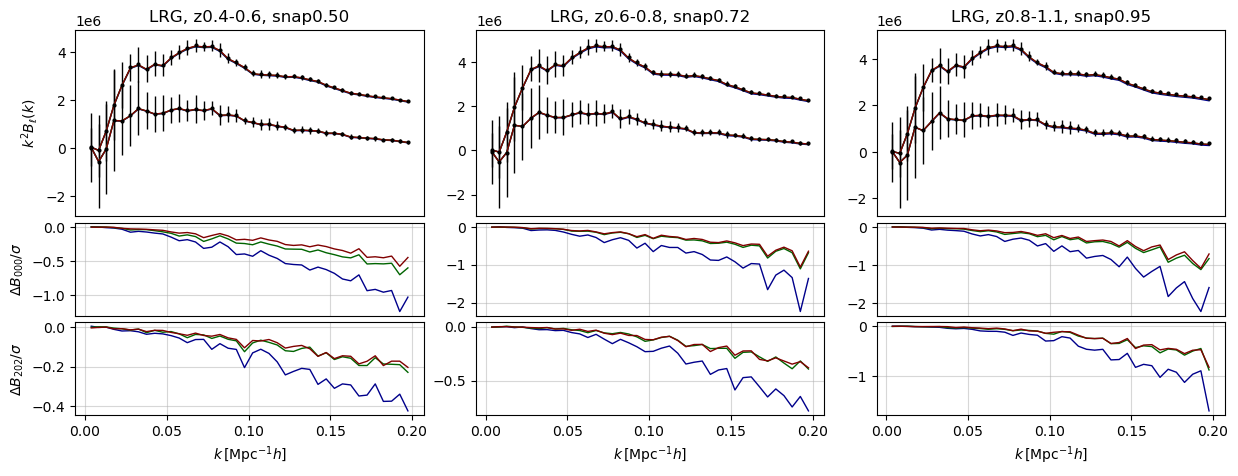

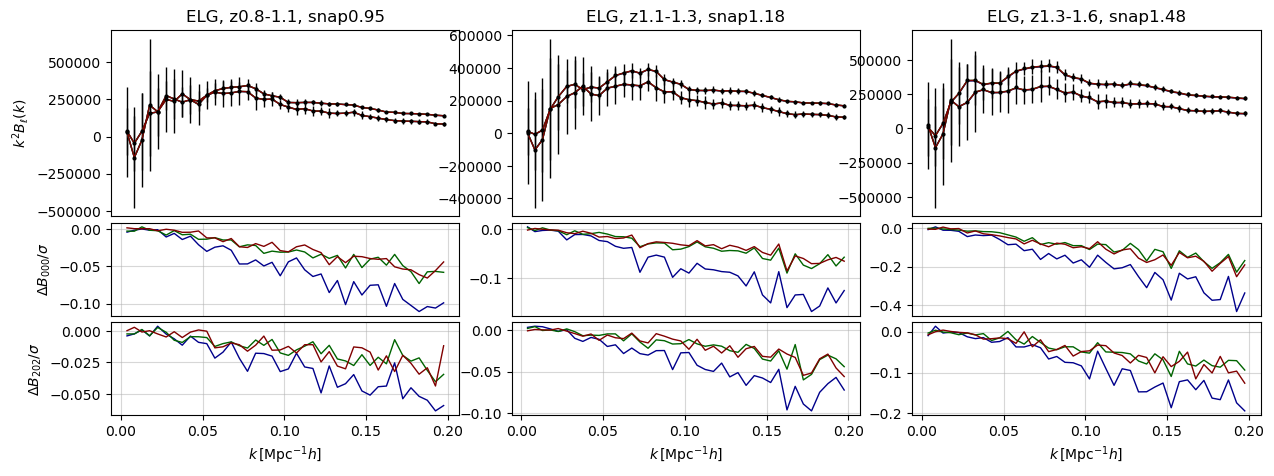

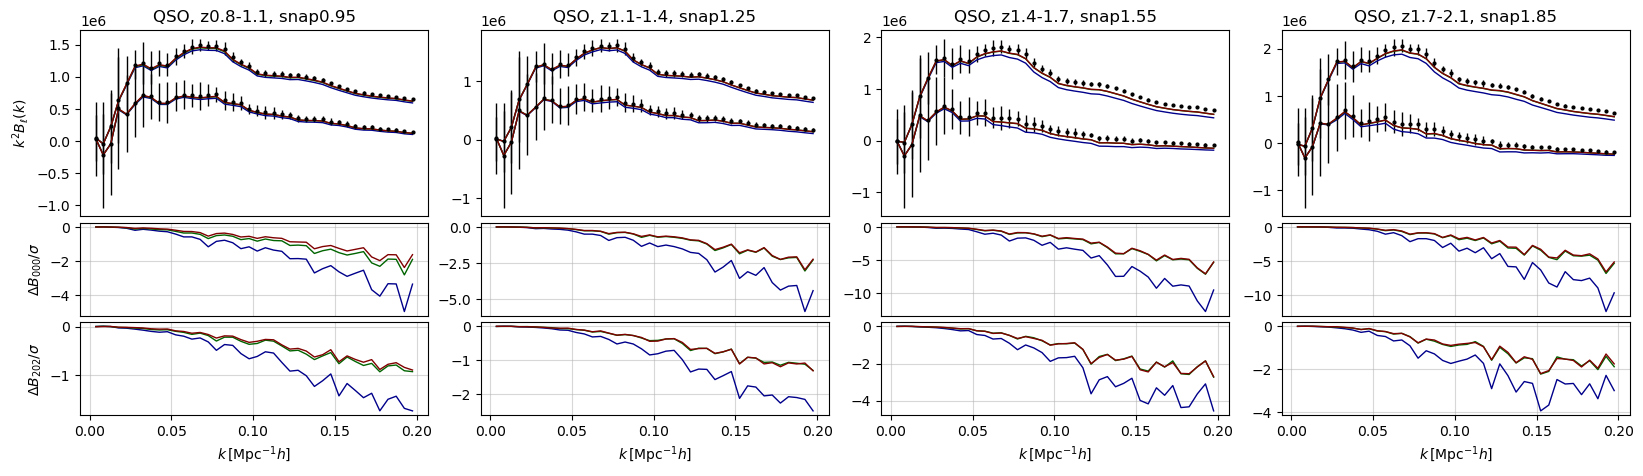

In [ ]:
# for three point statistics
from collections import defaultdict

corr = 'mesh3_sugiyama' #mesh3_sugiyama
domain = 'altmtl'
version = 'AbacusHF-v2'
tracers = ['BGS','LRG', 'ELG', 'QSO'][1:2]
zerrs =  ['False', 'repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
lenz = len(ZSNAPS)
labels = ['clean', '+dv_repeats', '+dv_err_empirical', '+dv_err_nonparam']
colors = ['black', 'darkblue', 'darkgreen', 'maroon']
zerr_labels = dict(zip(zerrs, labels))

# ells=[(0, 0, 0), (2, 2, 0), (2, 0, 2), (2, 2, 2)]
ells=[(0, 0, 0), (2, 0, 2)]

for tracer in tracers:
    fig = plt.figure(figsize = (lenz*5, 5))
    gs = gridspec.GridSpec(3, lenz, wspace=0.15, hspace= 0.05, height_ratios=[2,1,1])
    for indz, zsnap, zrange in zip(range(lenz), ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        for indv, zerr in enumerate(zerrs):
            s_all = []
            tps_all = defaultdict(list)
            for mock_id in range(25)[:]:
                data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, 'mock_id': mock_id, "use_dv": zerr}
                if 'mesh' in corr: data_arges.update(use_jax=True)
                fn = get_measurement_fn(**data_arges)
                setup_logging(level = 'warning')
                (s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')
                for ell in ells:
                    tps_all[ell].append(tps[ell])
            tps_mean = {ell: np.array(tps_all[ell]).mean(axis=0) for ell in ells}
            tps_std = {ell: np.array(tps_all[ell]).std(axis=0, ddof=1) for ell in ells}
            spow=2 
            for ell in ells:
                # plot the mean plots
                ax = plt.subplot(gs[indz])
                if zerr == 'False':
                    tps_mean_clean = tps_mean
                    tps_std_clean = tps_std
                    # ax.fill_between(s, s**spow*(tps_mean_fid[ill]-tps_std_fid[ill]),s**spow*(tps_mean_fid[ill]+tps_std_fid[ill]), color=colors[indv], alpha=0.15)
                    ax.errorbar(s, s**spow*tps_mean_clean[ell], yerr=s**spow*tps_std_clean[ell], fmt='o', markersize=2, lw=1, color=colors[indv], label=zerr_labels[zerr] if ell == (0,0,0) else None)
                else:
                    ax.plot(s, s**spow*tps_mean[ell], color=colors[indv], lw = 1, label=zerr_labels[zerr] if ell == (0,0,0) else None)
                if indz == 0:
                    ax.set_ylabel(TPS_LABELS[corr]['y'])
                # ax.legend(loc=2 if corr in ['wplog', 'mpslog'] else 1, fontsize=9)
                ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}, snap{zsnap:.2f}')
                ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                # plot the residual plots
                if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
                    if ell == (0,0,0):
                        ax = plt.subplot(gs[indz+lenz])
                        if indz == 0: ax.set_ylabel(TPS_LABELS[corr]['dy0'])
                        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                    elif ell == (2,0,2):
                        ax = plt.subplot(gs[indz+lenz*2])
                        ax.set_xlabel(TPS_LABELS[corr]['x'])
                        if indz == 0: ax.set_ylabel(TPS_LABELS[corr]['dy2'])
                    ax.grid(alpha=0.5)
                    err = tps_std_clean
                    ax.plot(s, (tps_mean[ell]-tps_mean_clean[ell])/err[ell], lw=1, color=colors[indv])
                    # ax.plot(s, (tps_mean[ell]/tps_mean_clean[ell]), lw=1, color=colors[indv])

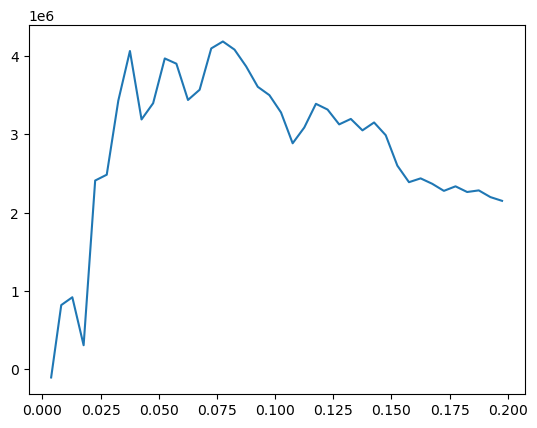

In [ ]:
fn = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/mesh3_spectrum_poles_sugiyama_LRG_z0.4-0.6_DR2_v2.0.h5'
(s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')


fn = 


plt.plot(s, s**2*tps[(0,0,0)])

In [ ]:
# for three point statistics
from plotting_tools import COLOR_OVERALL, TPS_LABELS
%load_ext autoreload
%autoreload 2
from collections import defaultdict

corr = 'mesh3_sugiyama' #mesh3_sugiyama
domain = 'cubic'
version = 'AbacusHF-v2'
tracers = ['BGS','LRG', 'ELG', 'QSO'][:1]

ZSNAPS, ZRANGES = REDSHIFT_ABACUSHF[version]
lenz = len(ZSNAPS)

zerrs =  ['False', 'verr_empirical', 'repeat']
colors = ['black', 'maroon', 'darkblue']
labels = ['clean', '+dv_repeats', '+dv_err']
zerr_labels = dict(zip(zerrs, labels))

for tracer in tracers:
    fig = plt.figure(figsize = (lenz*5, 5))
    gs = gridspec.GridSpec(3, lenz, wspace=0.15, hspace= 0.05, height_ratios=[2,1,1])
    for indz, zsnap, zrange in zip(range(lenz), ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        for indv, zerr in enumerate(zerrs):
            s_all = []
            tps_all = defaultdict(list)
            for mock_id in range(25)[:]:
                data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, 'mock_id': mock_id, "use_dv": zerr}
                if 'mesh' in corr: data_arges.update(use_jax=True)
                fn = get_measurement_fn(**data_arges)
                setup_logging(level = 'warning')
                (s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')
                for ell in ells:
                    tps_all[ell].append(tps[ell])
            tps_mean = {ell: np.array(tps_all[ell]).mean(axis=0) for ell in ells}
            tps_std = {ell: np.array(tps_all[ell]).std(axis=0, ddof=1) for ell in ells}
            spow=2 
            continue
            for ell in ells:
                # plot the mean plots
                ax = plt.subplot(gs[indz])
                if zerr == 'False':
                    tps_mean_clean = tps_mean
                    tps_std_clean = tps_std
                    # ax.fill_between(s, s**spow*(tps_mean_fid[ill]-tps_std_fid[ill]),s**spow*(tps_mean_fid[ill]+tps_std_fid[ill]), color=colors[indv], alpha=0.15)
                    ax.errorbar(s, s**spow*tps_mean_clean[ell], yerr=s**spow*tps_std_clean[ell], fmt='o', markersize=2, lw=1, color=colors[indv], label=zerr_labels[zerr] if ell == (0,0,0) else None)
                else:
                    ax.plot(s, s**spow*tps_mean[ell], color=colors[indv], lw = 1, label=zerr_labels[zerr] if ell == (0,0,0) else None)
                if indz == 0:
                    ax.set_ylabel(TPS_LABELS[corr]['y'])
                ax.legend(loc=2 if corr in ['wplog', 'mpslog'] else 1, fontsize=9)
                ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}, snap{zsnap:.2f}')
                ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                # plot the residual plots
                if zerr in ['repeat', 'verr_empirical']:
                    if ell == (0,0,0):
                        ax = plt.subplot(gs[indz+lenz])
                        if indz == 0: ax.set_ylabel(TPS_LABELS[corr]['dy0'])
                        if corr == 'wplog':
                            ax.set_xlabel(TPS_LABELS[corr]['x'])
                        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                    elif ell == (2,0,2):
                        ax = plt.subplot(gs[indz+lenz*2])
                        ax.set_xlabel(TPS_LABELS[corr]['x'])
                        if indz == 0: ax.set_ylabel(TPS_LABELS[corr]['dy2'])
                    err = tps_std_clean
                    ax.plot(s, (tps_mean[ell]-tps_mean_clean[ell])/err[ell], lw=1, color=colors[indv])  tps_std